# Behind Quantum Power: Parallelism and Phase Kickback

## Introduction

In the previous sections, we introduced several important building blocks of quantum computing, including qubits, superposition, quantum gates, multi-qubit systems, and the Deutsch algorithm. In this section, we review these ideas from a slightly different perspective and connect them through two important concepts: quantum parallelism and phase kickback. Rather than introducing many new mathematical tools, our goal is to see how the concepts we have already learned work together and how they can be used to design a quantum computation.

## A quick summary

### Single qubit

Before we continue with a more in-depth explanation of phase kickback and quantum parallelism, it is useful to briefly summarize what we have learned so far and look at some of these concepts from a slightly different perspective.

We have learned that the state of a single qubit can be written as $\ket{\psi} = \alpha\ket{0} + \beta\ket{1}$, where $\alpha$ and $\beta$ are complex numbers (consider them as real numbers here) satisfying $|\alpha|^2 + |\beta|^2 = 1$.

The states $\ket{0}$ and $\ket{1}$ are called the computational basis states. They are represented by the basis vectors 

$$\ket{0} = \begin{bmatrix}
1\\
0
\end{bmatrix}
\qquad \quad
\ket{1} =
\begin{bmatrix}
0\\
1
\end{bmatrix}
$$

Any valid single-qubit state can be expressed as a linear combination (or superposition) of these two basis states.

### Single qugate

A quantum gate is represented mathematically by a unitary transformation. Applying a quantum gate transforms one valid quantum state into another *while preserving its total probability*.
Two well-known single-qubit gates are the $X$ gate and the Hadamard gate $H$. Their actions on the computational basis states are 

$$
X\ket{0} = \ket{1} \quad X\ket{1} = \ket{0} 
\quad
H\ket{0} = \frac{1}{\sqrt{2}}(\ket{0}+\ket{1}) \quad H\ket{1} = \frac{1}{\sqrt{2}}(\ket{0}-\ket{1})
$$

The two states produced here by the Hadamard gate occur so frequently in quantum computing that we give them their own symbols:

$$
\ket{+}=\frac{1}{\sqrt{2}}(\ket{0}+\ket{1}),
\qquad
\ket{-}=\frac{1}{\sqrt{2}}(\ket{0}-\ket{1}).
$$

We can therefore write the action of the Hadamard gate more compactly as: $H\ket{0}=\ket{+}, \ H\ket{1}=\ket{-}$

These states also give us an opportunity to introduce another important concept: *eigenstates*.
In general, applying a quantum gate to a state changes the state. However, some special states are transformed only by multiplication by a single number. In other words, if a gate $U$ acts on a state $\ket{\psi}$ such that $U\ket{\psi}=\lambda\ket{\psi}$ ($\lambda$ is a number);
then $\ket{\psi}$ is called an eigenstate of $U$, and $\lambda$ is its corresponding eigenvalue.

Because quantum gates are unitary, their eigenvalues have magnitude $1$. Therefore, applying the gate to an eigenstate does not change the length of its state vector; it can only introduce a phase factor.

For example, consider applying the $X$ gate to $\ket{+}$:

$$
X\ket{+} = X\left(\frac{1}{\sqrt{2}}(\ket{0}+\ket{1})\right)
=
\frac{1}{\sqrt{2}}\left(X\ket{0}+X\ket{1}\right) = \frac{1}{\sqrt{2}}(\ket{1}+\ket{0}) = \ket{+}.
$$

Therefore, $X\ket{+}=1\ket{+}$. The state $\ket{+}$ is thus an eigenstate of $X$ with eigenvalue $+1$. Another very useful example is the state $\ket{-}$ which we leave here as an exercise.

**Exercise**: Calculate $X\ket{-}$. Is $\ket{-}$ also an eigenstate of the $X$ gate? If so, what is its eigenvalue?

### 2-qubit system

When we move from a single qubit to a two-qubit system, the number of computational basis states increases. A single qubit has two computational basis states, $\ket{0}$ and $\ket{1}$. A system of two qubits has four computational basis states: $\ket{00},\ \ket{01},\ \ket{10},\ \ket{11}$.

These states are constructed using the tensor product of the states of the individual qubits. For example, $\ket{01} = \ket{0}\otimes\ket{1}$.

Using the vector representations of $\ket{0}$ and $\ket{1}$, we obtain

$$
\ket{01}
=
\begin{bmatrix}
1\\
0
\end{bmatrix}
\otimes
\begin{bmatrix}
0\\
1
\end{bmatrix}
=
\begin{bmatrix}
0\\
1\\
0\\
0
\end{bmatrix}.
$$

Similarly, the four computational basis states can be represented as

$$
\ket{00}=
\begin{bmatrix}
1\\
0\\
0\\
0
\end{bmatrix},
\qquad
\ket{01}=
\begin{bmatrix}
0\\
1\\
0\\
0
\end{bmatrix},
\qquad
\ket{10}=
\begin{bmatrix}
0\\
0\\
1\\
0
\end{bmatrix},
\qquad
\ket{11}=
\begin{bmatrix}
0\\
0\\
0\\
1
\end{bmatrix}.
$$

Just as a single-qubit state can be a superposition of $\ket{0}$ and $\ket{1}$, a two-qubit state can be a superposition of all four computational basis states:

$$
\ket{\psi}
=
\alpha\ket{00}
+
\beta\ket{01}
+
\gamma\ket{10}
+
\delta\ket{11},
$$

where the amplitudes satisfy $|\alpha|^2+|\beta|^2+|\gamma|^2+|\delta|^2=1$.

This condition ensures that the total probability of all possible measurement outcomes is $1$. For example, we can place both qubits initially in the state $\ket{00}$ and apply a Hadamard gate to each qubit: $(H\otimes H)\ket{00}$.

Since $H\ket{0}=\ket{+}$, we obtain: $(H\otimes H)\ket{00} = \ket{+}\otimes\ket{+} = \frac{1}{2}(\ket{00}+\ket{01}+\ket{10}+\ket{11})$.

The resulting state is an equal superposition of all four computational basis states.

### 2-qubit gate

Just as we can apply gates to a single qubit, we can also apply gates that operate on two qubits together. One of the most important two-qubit gates is the controlled-NOT, or a CNOT gate.
The CNOT gate operates on two qubits with different roles. One is called the control qubit, and the other is called the target qubit. The target qubit is flipped only when the control qubit is $\ket{1}$.

Its action on the computational basis states is (we use the first qubit as the control and the second qubit as the target):

$$
\begin{aligned}
\operatorname{CNOT}\ket{00} = \ket{00},\
\operatorname{CNOT}\ket{01} = \ket{01},\
\operatorname{CNOT}\ket{10} = \ket{11},\
\operatorname{CNOT}\ket{11} = \ket{10}
\end{aligned}
$$

We can describe the same operation more compactly using two qubits $x$ and $y$: CNOT$\ket{x}\ket{y}=\ket{x}\ket{y\oplus x}$ , 
where $\oplus$ represents addition modulo $2$, also known as XOR.

Using $\oplus$ operation, when $x=0$, the target qubit remains unchanged because $y\oplus0=y$, but when $x=1$, the target qubit is flipped because $y\oplus1$ is the opposite of $y$; and this is exactly what we expect from a CNOT operation. For example, $\operatorname{CNOT}\ket{10}=\ket{1}\ket{0\oplus1}=\ket{1}\ket{1}=\ket{11}$.



## Quantum Parallelism

Before looking more closely at quantum parallelism, let us first recall how a classical function can be represented as a quantum operation.
Suppose we have a function $f:\{0,1\}\rightarrow\{0,1\}$

In a two-qubit quantum system, we use one qubit, $\ket{x}$, as the input and another qubit, $\ket{y}$, as the target (or auxiliary qubit). The quantum version of the function is represented by a unitary operation $U_f$ defined as

$$
U_f\ket{x}\ket{y}
=
\ket{x}\ket{y\oplus f(x)}.
$$

Notice two important characteristics of this operation. The input $\ket{x}$ passes through unchanged, while the target is modified according to the value of $f(x)$. A simple example is the function $f(x)=x$. For this function we have: $U_f \ket{x}\ket{y} = \ket{x}\ket{x \oplus y}$.

But, this is exactly the operation performed by a CNOT qugate, where $\ket{x}$ is the control qubit and $\ket{y}$ is the target qubit. 
So far, nothing particularly unusual has happened. We provided one input, and $U_f$ acted according to the value of $f$ for that input.
The interesting situation appears when the input qubit is in a superposition.

Suppose we prepare the first qubit in the state: $\ket{+}$ and the second qubit in $\ket{0}$. 
The combined state is therefore: $\ket{+}\ket{0}=\frac{1}{\sqrt{2}}(\ket{00}+\ket{10})$.

Now let's apply $U_f$. Because quantum operations are linear we will have:

$$
U_f
\left[
\frac{1}{\sqrt{2}}
(\ket{0}\ket{0}+\ket{1}\ket{0})
\right]
=
\frac{1}{\sqrt{2}}
\left(
U_f\ket{0}\ket{0}
+
U_f\ket{1}\ket{0}
\right).
$$

Using the definition of $U_f$ the result will be: 
$
\frac{1}{\sqrt{2}}
\left(
\ket{0}\ket{f(0)}
+
\ket{1}\ket{f(1)}
\right)
$

For our example, $f(x)=x$, this becomes: 
$
\frac{1}{\sqrt{2}}(\ket{00}+\ket{11})
$

What we experience here is that with a single application of $U_f$, the transformation has acted on both components of the superposition. This is the basic idea behind quantum parallelism.
Intuitively, instead of preparing the input qubit as only $\ket{0}$ or only $\ket{1}$, we prepare it in a superposition containing both, i.e.:
$
\frac{1}{\sqrt{2}}(\ket{0}+\ket{1}).
$

When $U_f$ is applied to this state, it does not select one of these components at a time while ignoring the other. Because quantum operations are linear, $U_f$ acts on each component of the superposition according to the same rule and this act on all the components is parallel. In our two-qubit example, this means that one application of $U_f$ produces:
$
\frac{1}{\sqrt{2}}
\left(
\ket{0}\ket{f(0)}
+
\ket{1}\ket{f(1)}
\right).
$

In this sense, the function has been applied to both possible inputs, $0$ and $1$, within a single quantum operation. This ability to apply an operation to all components of a superposition is what we mean by quantum parallelism.

It is useful to think of the superposition as providing several computational components on which the same quantum operation can act. For a single input qubit, there are two such components, corresponding to $\ket{0}$ and $\ket{1}$. More generally, $n$ qubits can form a superposition containing all $2^n$ computational basis states, and a quantum operation can act on all of these components through a single application of that operation.

However, there is an important limitation. Quantum parallelism does not mean that we can simply measure the resulting state and read both $f(0)$ and $f(1)$. A measurement produces only one outcome according to the probabilities encoded in the quantum state. The real power comes from designing the rest of the quantum algorithm so that the different components of the superposition interfere, allowing us to extract some useful global property of the function.

This is exactly what happens in the Deutsch algorithm.
Recall that the goal of the Deutsch algorithm is not to determine the individual values of $f(0)$ and $f(1)$. Instead, we want to determine whether $f$ is constant, i.e. $f(0)=f(1)$, or balanced, $f(0)\neq f(1)$.

In the Deutsch algorithm, after the initial Hadamard gates, the input qubit is in the state $\ket{+}$, while the target qubit is in the state $\ket{-}$.
Therefore, when we apply $U_f$, it does not receive just one classical input such as $\ket{0}$ or $\ket{1}$. The input qubit contains both computational basis states in superposition:

$$
U_f(\ket{+}\ket{-})
=
U_f
\left[
\frac{1}{\sqrt{2}}
(\ket{0}+\ket{1})\ket{-}
\right].
$$

By linearity,

$$
\frac{1}{\sqrt{2}}
\left(
U_f\ket{0}\ket{-}
+
U_f\ket{1}\ket{-}
\right).
$$

Thus, a single application of $U_f$ acts on the components corresponding to both possible inputs, $x=0$ and $x=1$. This is the quantum-parallelism part of the Deutsch algorithm.


## Phase Kickback

We have seen that quantum parallelism allows a quantum operation to act on different components of a superposition at the same time. There is another important phenomenon that appears frequently in quantum algorithms: phase kickback.

Instead of starting with its formal definition, let us first construct a very small circuit and observe what happens.

### An Experiment 

Consider a two-qubit system. We will call the first qubit $\ket{x}$ and the second qubit $\ket{y}$.
Start both qubits in $\ket{0}$:
$
\ket{x}\ket{y}=\ket{0}\ket{0}.
$

Now construct the following circuit using as few gates as possible:

1. Prepare the first qubit in $\ket{1}$.
2. Prepare the second qubit in $\ket{-}$.
3. Use the first qubit as the control of a CNOT gate and the second qubit as its target.

(Recall that $\ket{-}=\frac{1}{\sqrt{2}}(\ket{0}-\ket{1})$)

Before continuing, try to answer the following questions:

* What is the two-qubit state immediately before the CNOT?
* What does the CNOT do to the target qubit when the control is $\ket{1}$?
* What is the final state?
* Does the target qubit actually change?
* If the target does not change, can you explain what has changed?

Try to work out the result before continuing.

#### Trying it with Qiskit

We can also investigate the same circuit using Qiskit.
Starting from $\ket{00}$, an $X$ gate prepares the first qubit in $\ket{1}$. To prepare the second qubit in $\ket{-}$, we first apply $X$ and then $H$.
The circuit can therefore be implemented as follows with the calculation of the final state. 
Run the code and compare the result with your own calculation.

**Note:** Be careful when reading the Qiskit statevector (the printed result). Qiskit displays computational basis states using the ordering $\ket{q_1q_0}$, so the displayed vector may initially look different from an expression written algebraically, i.e. $\ket{x}\ket{y}$.

Did you obtain the same result as you predicted? Take some time to carefully interpret the printed output. Note that the quantum state is displayed in its complete form, including both the real and imaginary components of each amplitude. In this case, the imaginary components are all zero. Therefore, you can focus only on the real parts when interpreting the result.

Statevector([ 0.        +0.j, -0.70710678+0.j,  0.        +0.j,
              0.70710678+0.j],
            dims=(2, 2))
{np.str_('01'): np.complex128(-0.7071067811865475+0j), np.str_('11'): np.complex128(0.7071067811865475+0j)}


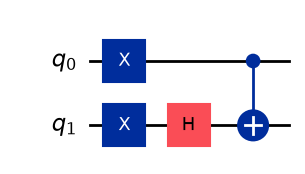

In [4]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
qc = QuantumCircuit(2)
# Prepare q0 in |1>
qc.x(0)
# Prepare q1 in |->
qc.x(1)
qc.h(1)
# q0 = control, q1 = target
qc.cx(0, 1)

state = Statevector.from_instruction(qc)
print(state)
print(state.to_dict())
qc.draw("mpl")


### What happened?

In our experiment, immediately before the CNOT, our state is: 
$\ket{1}\ket{-}$.
Since the control qubit is $\ket{1}$, the CNOT applies an $X$ operation to the target:
$\text{CNOT } \ket{1}\ket{-}=\ket{1}X\ket{-}$.

From our earlier discussion of eigenstates, we know that $\ket{-}$ is an eigenstate of $X$ with eigenvalue $-1$, i.e.:
$
X\ket{-}=-\ket{-}.
$

Therefore:
$\text{CNOT } \ket{1}X\ket{-}=-\ket{1}\ket{-}$.

Something interesting has happened. The CNOT tried to apply $X$ to the target, but applying $X$ to $\ket{-}$ returns the same state multiplied by $-1$.
The target is still $\ket{-}$. Instead, the signed has changed (a phase factor has appeared):
$\ket{1}\ket{-}$ became $-\ket{1}\ket{-}$. This is the basic mechanism behind phase kickback.

The operation that was controlled by the first qubit acted on the second qubit, but because the second qubit was in an eigenstate of that operation, its eigenvalue appeared as a phase factor multiplying the state.

There is one subtle point here. The factor $-1$ in this particular example is a global phase.

$
\ket{1}\ket{-}
\quad\text{and}\quad
-\ket{1}\ket{-}
$
 describe physically equivalent states by themselves. Therefore, this circuit alone does not yet give us something that can be distinguished by measurement.

A global phase occurs when the entire quantum state is multiplied by the same phase factor, such as $-1$. For example, $\ket{\psi}$ and $-\ket{\psi}$ represent the same physical quantum state, because this overall change cannot be observed by measurement. A relative phase, however, changes the phase of one component relative to another. For example, $\frac{1}{\sqrt{2}}(\ket{0}+\ket{1})$ and $\frac{1}{\sqrt{2}}(\ket{0}-\ket{1})$ are physically different states. Although they give the same probabilities when measured directly in the computational basis, the relative minus sign can change how the components interfere later in a quantum circuit. In short, a phase applied to the whole state does not matter, but a phase difference between parts of the state can matter.

Phase kickback becomes useful when we utilize the properties of relative phase. To do this we set the control itself in a superposition. Then the phase can be attached to only one component of that superposition, producing a relative phase that can later affect interference. Let us see this directly.

#### Set up

Instead of preparing the first qubit in $\ket{1}$, prepare it $\ket{+}$.
The complete state before the CNOT becomes $\ket{+}\ket{-}$.
Using linearity, we can unfold $\ket{+}$ and distribute it over $\ket{-}$. Then we look at the two components separately:

$$
\frac{1}{\sqrt{2}}
\left(
\ket{0}\ket{-}
+
\ket{1}\ket{-}
\right).
$$

Now we can apply CNOT gate. For the $\ket{0}$ component, the CNOT does nothing, but for the $\ket{1}$ component, it applies $X$ to the target which is $\ket{-}$:

$$
\ket{0}\ket{-}
\longrightarrow
\ket{0}\ket{-}.
\qquad 
\ket{1}\ket{-}
\longrightarrow
\ket{1}X\ket{-}
=
-\ket{1}\ket{-}.
$$

Putting the two components back together gives

$$
\text{CNOT } \ket{+}\ket{-}
=
\frac{1}{\sqrt{2}}
\left(
\ket{0}\ket{-}
-
\ket{1}\ket{-}
\right)
$$

We can factor out the unchanged target state:

$$
\text{CNOT } \ket{+}\ket{-}
=
\frac{1}{\sqrt{2}}
(\ket{0}-\ket{1})\ket{-}.
$$

But:

$$
\frac{1}{\sqrt{2}}(\ket{0}-\ket{1})
=
\ket{-}.
$$

Therefore:

$$
\text{CNOT} \ket{+}\ket{-} = \ket{-}\ket{-}.
$$

This is much more interesting.
The target qubit remains $\ket{-}$, but the control has changed from $\ket{+}$ to $\ket{-}$.

We observed that the phase produced by the operation on the target has effectively appeared in the control. This is why the phenomenon is called phase kickback.

A useful intuition is:
*When a controlled operation acts on a target that is an eigenstate of that operation, the target can remain unchanged while its eigenvalue appears as a phase on the corresponding component of the control*.

For our CNOT example, the controlled operation is $X$, and $X\ket{-}=-\ket{-}$.
The eigenvalue $-1$ is therefore what gets **kicked back** into the phase of the control.

##### Exercise

Review the steps and operations of the Deutsch algorithm. Reconstruct the quantum circuit and initialize the two qubits, $\ket{x}$ and $\ket{y}$, as described in the algorithm. Experiment with different oracles representing both constant and balanced functions, and measure the final state of $\ket{x}$. As you work through each case, inspect the state of the system at the different stages of the circuit. Pay particular attention to the application of $U_f$: identify where phase kickback occurs, describe how it changes the phase of $\ket{x}$, and explain how this phase information eventually affects the final measurement.

#### Phase kickback in the Deutsch algorithm: Formal Review

You can continue with this section if you are more curious about formal explanation of the effect of phase kickback in the Deutsch algorithm. 

Recall that the oracle in Deutsch’s algorithm operates as

$$
U_f\ket{x}\ket{y}
=
\ket{x}\ket{y\oplus f(x)}.
$$

We can also write this as

$$
U_f\ket{x}\ket{y}
=
\ket{x}X^{f(x)}\ket{y}.
$$

This is simply another way of representing the application of $f(x)$. This notation is particularly useful because $f(x)$ can take only two possible values: $0$ or $1$.
If $f(x)=0$, then $X^{f(x)}=X^0=I$, so nothing happens to the target.
But, if $f(x)=1$, then $X^{f(x)}=X^1=X$, so the target is flipped.

Now recall that in the Deutsch algorithm we deliberately prepare the target qubit in $\ket{-}$.
Therefore, 
$$
U_f\ket{x}\ket{-}
=
\ket{x}X^{f(x)}\ket{-}.
$$

We already know that $X\ket{-}=-\ket{-}$.
Consequently,

$$
X^{f(x)}\ket{-}
=
(-1)^{f(x)}\ket{-}
$$

This gives us the important relation

$$
\boxed{
U_f\ket{x}\ket{-}
=
(-1)^{f(x)}\ket{x}\ket{-}
}
$$

The target qubit remains $\ket{-}$, while the value of $f(x)$ appears as a phase:

$$
\left\{
    \begin{array}{ll}
f(x)=0
\quad\Rightarrow\quad
(-1)^{f(x)}=+1,
\\
f(x)=1
\quad\Rightarrow\quad
(-1)^{f(x)}=-1.
    \end{array}
\right.
$$

Now remember that the input qubit in the Deutsch algorithm is not simply $\ket{0}$ or $\ket{1}$. After applying the first Hadamard gate, it is $\ket{+}$. 
Therefore, immediately before $U_f$, the two-qubit state is

$$
\frac{1}{\sqrt{2}}
(\ket{0}+\ket{1})\ket{-}.
$$

Applying $U_f$ gives

$$
\frac{1}{\sqrt{2}}
\left(
U_f\ket{0}\ket{-}
+
U_f\ket{1}\ket{-}
\right).
$$

Using phase kickback,

$$

\frac{1}{\sqrt{2}}
\left(
(-1)^{f(0)}\ket{0}
+
(-1)^{f(1)}\ket{1}
\right)
\ket{-}.
$$

This equation captures the key role of phase kickback in Deutsch’s algorithm.

The values $f(0)$ and $f(1)$ have not simply been written into the target qubit. Instead, they have been encoded into the phases of the components of the input qubit.

If $f$ is constant, then $f(0)=f(1)$. Both components therefore receive the same phase. The input qubit is, up to an irrelevant global phase, $\ket{+}$.
If $f$ is balanced, then $f(0)\neq f(1)$. One component receives a different sign from the other. The input qubit is then, up to a global phase, $\ket{-}$.

The final Hadamard gate converts these two possibilities into computational basis states:

$$
H\ket{+}=\ket{0},
\qquad
H\ket{-}=\ket{1}.
$$

Therefore, the final measurement can distinguish between the two cases:

$$
\ket{x} =
\left\{
    \begin{array}{ll}
\ket{0}
\quad\Rightarrow\quad
f\text{ is constant},
\\
\ket{1}
\quad\Rightarrow\quad
f\text{ is balanced}.
    \end{array}
\right.
$$

We can now see how the ideas fit together. Quantum parallelism allows $U_f$ to act on the components corresponding to both $x=0$ and $x=1$ in a single application. Phase kickback encodes the corresponding function values into their phases. Finally, interference, created by the last Hadamard gate, turns the relative phase information into something that we can observe through measurement.

## Summary

Quantum parallelism and phase kickback provide two fundamental techniques that appear in the design of many quantum algorithms. Quantum parallelism allows a quantum operation to act on multiple components of a superposition in a single application. However, this alone does not give us access to all of the resulting information, since a measurement produces only a limited classical outcome. Phase kickback provides a way to encode useful information into the relative phases of a quantum state. These phases can then be manipulated through interference so that the information we are interested in becomes observable.

The Deutsch algorithm gives us a simple example of how these ideas work together. Quantum parallelism allows the oracle to act on the components associated with both possible inputs, while phase kickback transfers information about the function values into their relative phases. The final Hadamard gate then uses interference to convert this phase information into a measurable result. Understanding these two concepts therefore provides an important foundation for understanding quantum algorithm design: they show how properties such as superposition, phase, and interference can be combined to extract information in ways that are different from classical computation and, for suitable problems, can enable quantum algorithms to outperform their classical counterparts.